# Exploratory Data Analysis (EDA) cho Dữ liệu Ảnh Phi Cấu Trúc

Notebook này thực hiện phân tích thống kê mô tả toàn diện (EDA) và ablation study đánh giá tác động của các phương pháp tiền xử lý cho dữ liệu ảnh phi cấu trúc, dựa trên cấu hình đã định nghĩa trong `IMAGE_EDA_CONFIG.md`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import image_eda_utils as utils

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


## **1. Configuration & Initialization**
Thiết lập các biến môi trường và thư mục lưu trữ kết quả đầu ra (artifacts).

In [2]:
PROJECT_ROOT = '..'
LABELED_DIR = os.path.join(PROJECT_ROOT, 'image_labeling', 'data', 'labeled')
OUTPUT_DIR = 'outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_SIZE = 800
RANDOM_SEED = 42
WORKING_SIZE = (128, 128)
KNN_K = 5

## **2. Load Data**
Quét thư mục lấy danh sách tập tin ảnh. Thực hiện lấy mẫu phân tầng (stratified sampling) đối với các xử lý nặng, trong khi các tác vụ đếm và quét mã băm (pHash) sẽ chạy trên toàn bộ tập dữ liệu.

In [3]:
df_all = utils.load_image_paths_and_labels(LABELED_DIR)
print(f"Total images found: {len(df_all)}")

df_sampled = utils.stratified_sample(df_all, SAMPLE_SIZE, RANDOM_SEED, stratified=True)
print(f"Sampled images for heavy processing: {len(df_sampled)}")

if len(df_sampled) > 0:
    images, labels = utils.load_images(df_sampled, target_size=WORKING_SIZE)
else:
    images, labels = np.array([]), np.array([])
    print("No images to load. Ensure LABELED_DIR is correctly populated.")

Total images found: 7987
Sampled images for heavy processing: 518


Loading Images: 100%|██████████| 518/518 [00:06<00:00, 80.34it/s] 


## **Part 1: Descriptive Statistical Analysis (Basic EDA)**

### **1.1 Pixel Value Distribution**
Tính và trực quan hóa phân phối giá trị cường độ điểm ảnh trên toàn tập (histogram, KDE) theo từng kênh màu (Red, Green, Blue).

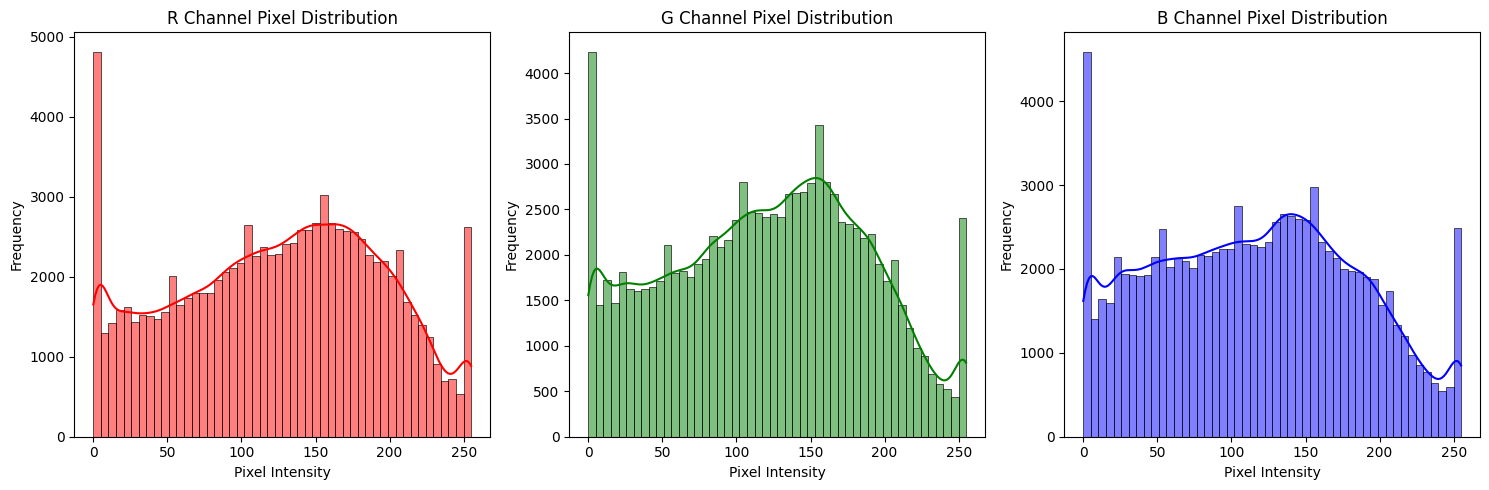

Saved pixel distribution plot to outputs/pixel_distribution.png


In [4]:
if len(images) > 0:
    utils.plot_pixel_distributions(images, labels, OUTPUT_DIR)
    print(f"Saved pixel distribution plot to {OUTPUT_DIR}/pixel_distribution.png")

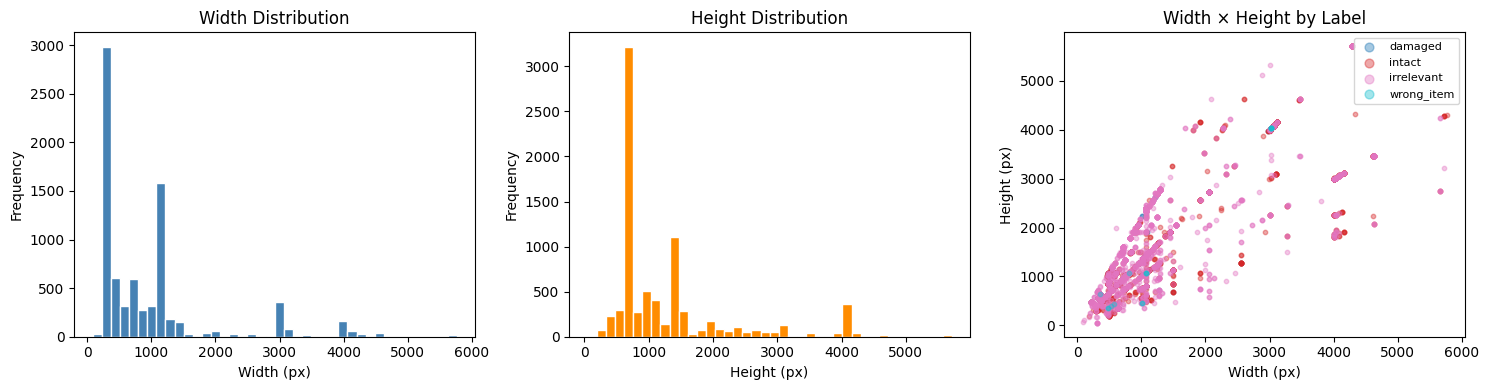

Saved → outputs\resolution_distribution.png

Resolution descriptive statistics:
        width  height  aspect_ratio
count  7987.0  7987.0        7987.0
mean    975.6  1256.1           0.8
std     931.5   967.3           0.4
min      85.0    51.0           0.3
25%     360.0   640.0           0.6
50%     692.0   834.0           0.7
75%    1080.0  1440.0           0.8
max    5760.0  5712.0           6.1

Images below 64×64 px: 6 (0.08%)
     label  count
irrelevant      6


In [6]:
res_df = utils.analyze_resolution_distribution(
    df_all, OUTPUT_DIR, base_dir=LABELED_DIR
)

### **1.2 Class Imbalance**
Tính tỉ lệ mỗi lớp và kiểm tra xem có lớp nào chiếm tỉ lệ vượt mức 3x so với lớp ít nhất không (dấu hiệu mất cân bằng nghiêm trọng).

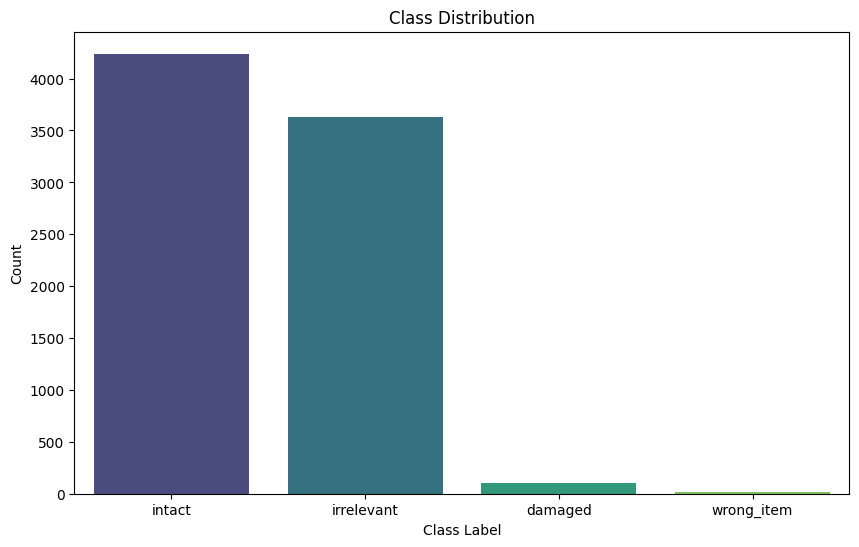

Class Counts:
label
intact        4241
irrelevant    3628
damaged        101
wrong_item      17
Name: count, dtype: int64

Is dataset imbalanced (>3x): True


In [7]:
class_counts, is_imbalanced = utils.analyze_class_imbalance(df_all, 3.0, OUTPUT_DIR)
print("Class Counts:")
print(class_counts)
print(f"\nIs dataset imbalanced (>3x): {is_imbalanced}")

### **1.3 Duplicate or nearly duplicate image detection (pHash)**
Quét toàn bộ tập dữ liệu, tính hàm băm cảm nhận (perceptual hash). Báo cáo tỉ lệ trùng lặp với ngưỡng Hamming distance = 10.

Computing pHash:   0%|          | 0/7987 [00:00<?, ?it/s]

Finding Duplicates: 100%|██████████| 7987/7987 [01:14<00:00, 106.88it/s] 


Duplication Rate: 0.01%
Found 2984 duplicate pairs. Report saved to outputs/duplicate_report.csv
[INFO] Using columns — img1: 'img1', img2: 'img2', distance: 'distance'
  Total duplicate pairs      : 2984
  Intra-class pairs          :  2925 (98.0%)
  Cross-class pairs          :    59 (2.0%)
  Exact duplicates (dist=0)  :  1351 (45.3%)
  Cross-class exact          :    27  ← potential mislabelling


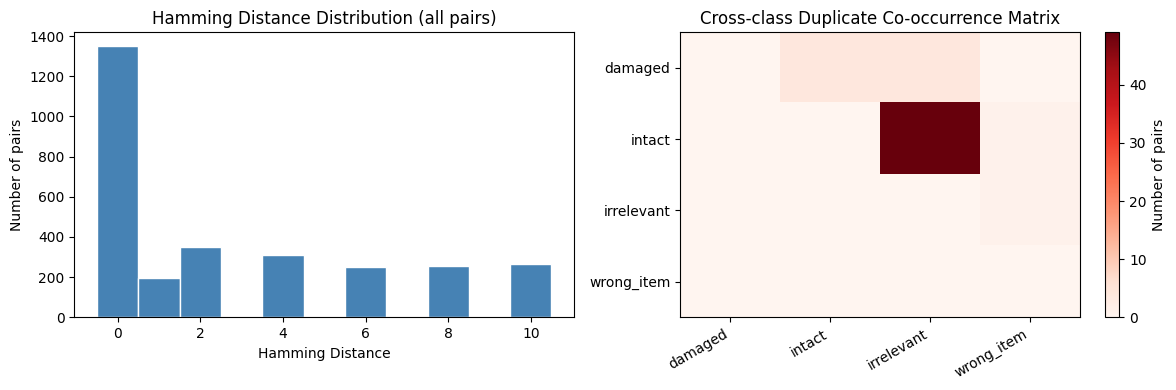

Saved → outputs\duplicate_analysis.png

Cross-class exact duplicate pairs — priority review (n=27):
                                                                  img1  label1                                                                      img2     label2  distance
   ..\image_labeling\data\labeled\damaged\frames_98836109dc6c_img3.jpg damaged        ..\image_labeling\data\labeled\intact\frames_ed7836383cdb_img3.jpg     intact         0
..\image_labeling\data\labeled\damaged\raw_media_9ecec44df5c0_img2.jpg damaged     ..\image_labeling\data\labeled\intact\raw_media_2c77b2c954f9_img2.jpg     intact         0
..\image_labeling\data\labeled\damaged\raw_media_9ecec44df5c0_img3.jpg damaged     ..\image_labeling\data\labeled\intact\raw_media_2c77b2c954f9_img3.jpg     intact         0
 ..\image_labeling\data\labeled\intact\raw_media_08a7dfcbd29d_img1.jpg  intact ..\image_labeling\data\labeled\irrelevant\raw_media_6fdd828b63bb_img1.jpg irrelevant         0
 ..\image_labeling\data\labele

In [8]:
dup_rate, dup_df = utils.detect_duplicates_phash(df_all, threshold=10, output_dir=OUTPUT_DIR)
print(f"Duplication Rate: {dup_rate:.2%}")
print(f"Found {len(dup_df)} duplicate pairs. Report saved to {OUTPUT_DIR}/duplicate_report.csv")
dup_df_analyzed = utils.analyze_duplicate_report(dup_df, OUTPUT_DIR)

### **1.4 Analysis of overall contrast and brightness**
Chuyển ảnh sang dạng Grayscale để tính cường độ trung bình (Mean Intensity) và độ lệch chuẩn (Standard Deviation) đại diện cho độ sáng và độ tương phản của ảnh, trình bày qua boxplot phân lớp.

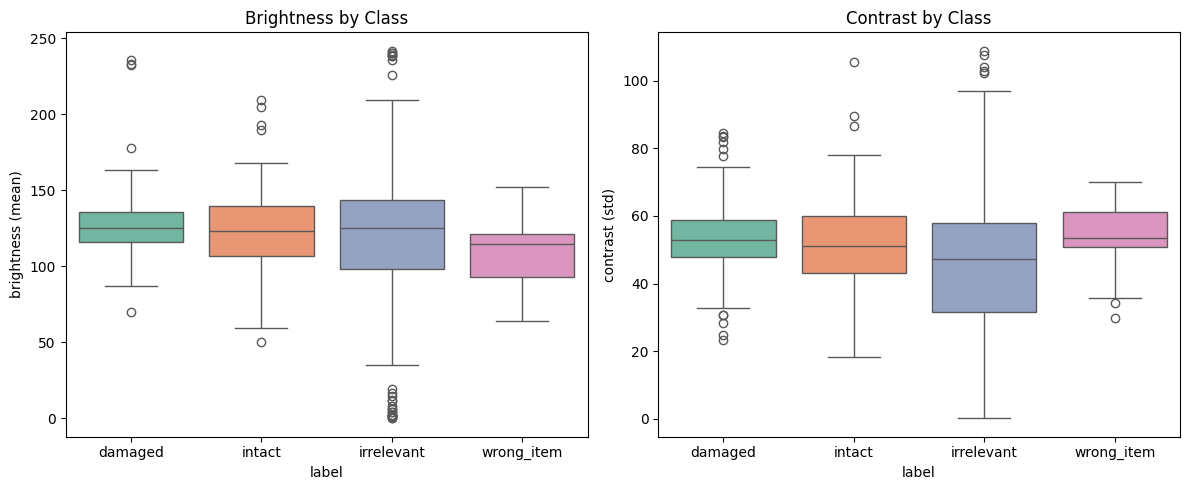

Mean Intensity & Contrast per class:


,brightness (mean),contrast (std)
label,,
damaged,127.870416,53.379382
intact,123.030160,51.361945
irrelevant,116.917651,45.596897
wrong_item,107.302756,53.577816


In [9]:
if len(images) > 0:
    brightness_contrast_stats = utils.analyze_brightness_contrast(images, labels, OUTPUT_DIR)
    print("Mean Intensity & Contrast per class:")
    display(brightness_contrast_stats)

In [10]:
outlier_df, abnormal_df = utils.detect_brightness_contrast_outliers(
    images, labels, df_sampled, OUTPUT_DIR
)

  Images inspected      : 518
  Outliers detected     : 49 (9.5%)

  Thresholds applied:
    Too dark            : mean_intensity < 50.0
    Overexposed         : mean_intensity > 200.0
    Low contrast        : std_intensity  < 20.0

Outlier breakdown by label and flag type:
     label                  flags  count
   damaged            overexposed      3
    intact           low_contrast      1
    intact            overexposed      2
    intact               too_dark      1
irrelevant           low_contrast      3
irrelevant            overexposed     10
irrelevant               too_dark     10
irrelevant too_dark, low_contrast     19

Outlier report saved → outputs\outlier_report.csv


## **Part 2: Assessing the Impact of Pre-treatment Techniques (Ablation Study)**
So sánh kết quả phân loại đơn giản (dùng k-NN) trước và sau khi áp dụng mỗi kỹ thuật tiền xử lý.

### **2.1 Change the size and quality of the image**
Resize về các kích thước 32x32, 64x64, 128x128. Với mỗi kích thước, tính chỉ số hình học cấu trúc (SSIM) và PSNR so với ảnh gốc để định lượng mất mát thông tin.

Analyzing Resize 128x128: 100%|██████████| 100/100 [00:00<00:00, 411.88it/s]


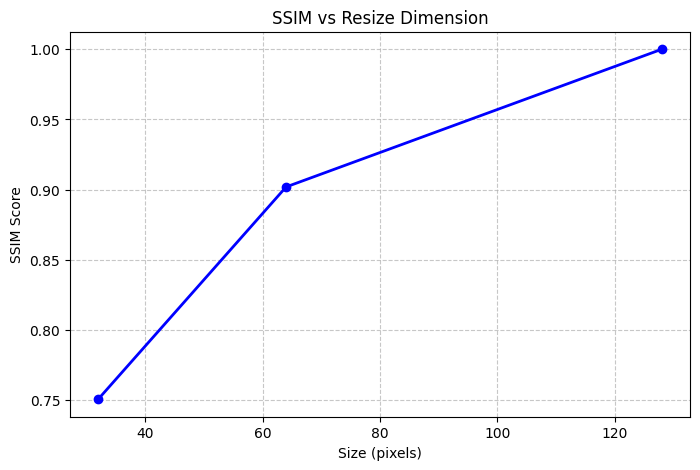

,size,ssim,psnr,accuracy
0,32,0.750725,26.085742,0.500000
1,64,0.901916,30.473898,0.471154
2,128,1.000000,inf,0.451923


In [11]:
if len(images) > 0:
    resize_results = utils.analyze_resize_quality(images, labels, [32, 64, 128], OUTPUT_DIR, RANDOM_SEED, KNN_K)
    display(resize_results)

### **2.2 Color Space Conversion**
Chuyển đổi sang RGB, Grayscale, HSV, và LAB. Đo lường phương sai giải thích (Explained Variance) bằng PCA (k=50) và khả năng phân loại.

Analyzing Color Spaces: 100%|██████████| 4/4 [00:08<00:00,  2.08s/it]


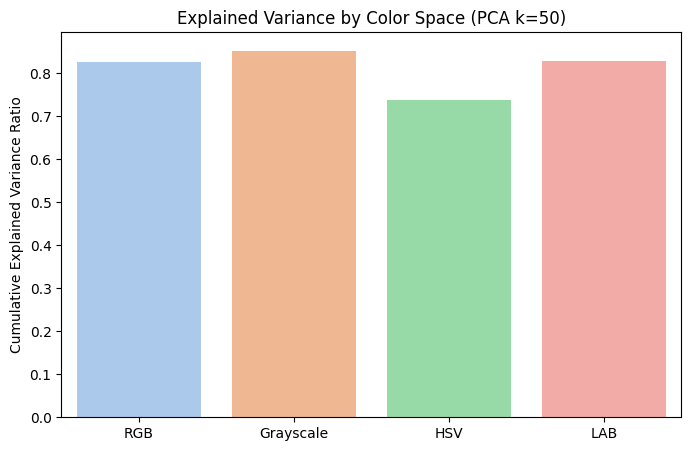

,color_space,explained_variance,accuracy
0,RGB,0.825610,0.451923
1,Grayscale,0.852087,0.432692
2,HSV,0.736743,0.509615
3,LAB,0.826939,0.423077


In [12]:
if len(images) > 0:
    color_space_results = utils.analyze_color_spaces(images, labels, k_components=50, output_dir=OUTPUT_DIR, knn_k=KNN_K)
    display(color_space_results)

### **2.3 Normalization**
Áp dụng Min-Max [0,1], Min-Max [-1,1], Z-score toàn tập, Z-score theo kênh. Kiểm định sự khác biệt phân phối trước và sau chuẩn hóa thông qua Kolmogorov-Smirnov (KS test).

In [13]:
if len(images) > 0:
    norm_results, ks_p_value = utils.analyze_normalization(images, labels, knn_k=KNN_K)
    print(f"KS Test (Original vs Z-score Global) p-value: {ks_p_value:.4e}")
    display(norm_results)

Analyzing Normalizations...
KS Test (Original vs Z-score Global) p-value: 0.0000e+00


,method,accuracy
0,Original,0.451923
1,"MinMax [0,1]",0.451923
2,"MinMax [-1,1]",0.451923
3,Z-score Global,0.451923
4,Z-score Per-Channel,0.451923


### **2.4 Data Augmentation**
Sử dụng Albumentations áp dụng pipeline 5 phép biến đổi. Tác động được đánh giá trực quan thông qua t-SNE (tập gốc so với tập tăng cường).

Augmenting Images: 100%|██████████| 518/518 [00:00<00:00, 1273.45it/s]


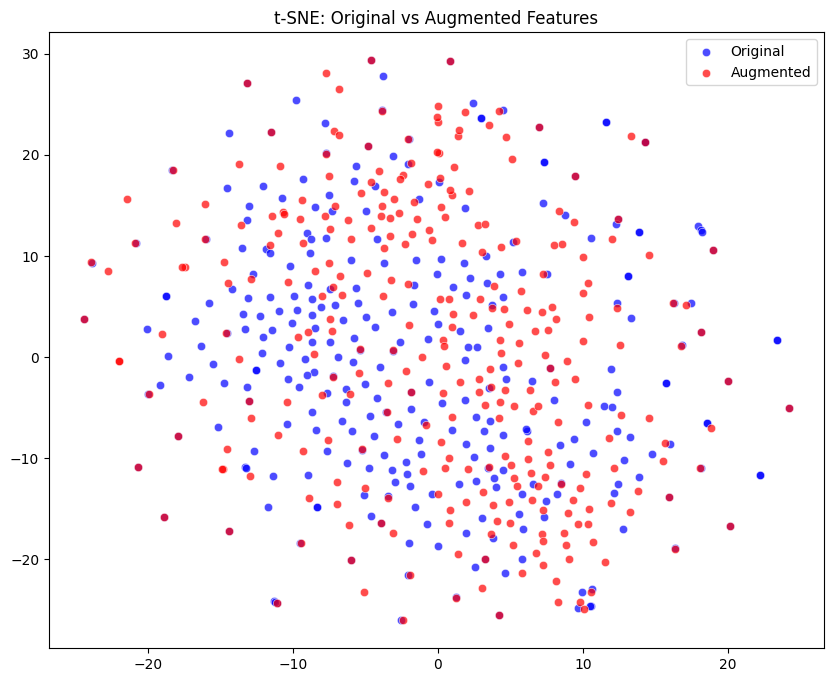

Accuracy on Original dataset: 0.4519
Accuracy on Augmented dataset: 0.4423


In [14]:
if len(images) > 0:
    acc_orig, acc_aug = utils.apply_augmentation_pipeline(images, labels, OUTPUT_DIR, knn_k=KNN_K)
    print(f"Accuracy on Original dataset: {acc_orig:.4f}")
    print(f"Accuracy on Augmented dataset: {acc_aug:.4f}")

### **2.5 PCA analysis on image feature space**
Giảm chiều không gian đặc trưng thông qua PCA. Xác định ngưỡng thành phần giải thích 90%, 95% và 99% phương sai (Scree plot). Trực quan PCA và t-SNE 2D để xem xét mức độ tách biệt của các lớp.

Performing PCA Analysis...


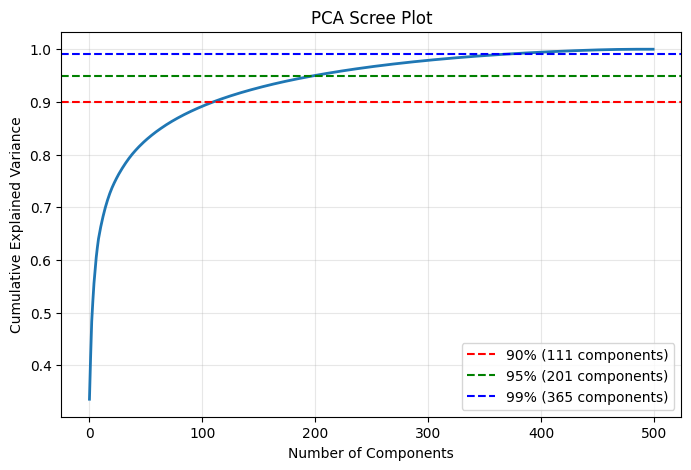

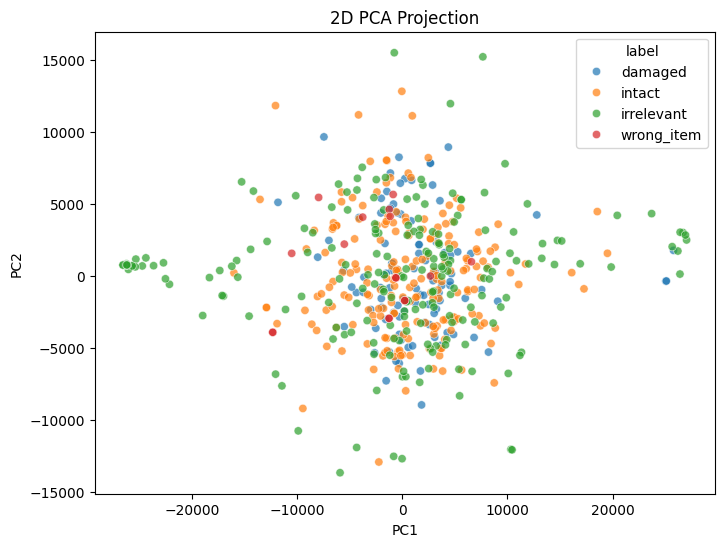

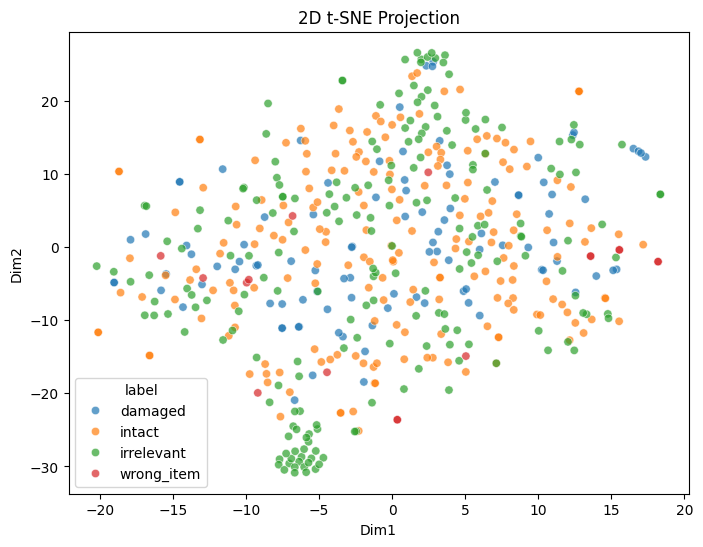

Components needed for explained variance thresholds:
{'n_90': np.int64(111), 'n_95': np.int64(201), 'n_99': np.int64(365)}


In [15]:
if len(images) > 0:
    pca_components = utils.perform_pca_analysis(images, labels, OUTPUT_DIR)
    print("Components needed for explained variance thresholds:")
    print(pca_components)

### **2.6 Edge Detection and Local Feature Analysis**
Dùng các bộ lọc Sobel, Prewitt, Canny để trích xuất biên cạnh. Tính Edge Density (Mật độ cạnh) và chạy kiểm định One-way ANOVA để xem biến số này có phân biệt rõ các lớp hay không.

Detecting Edges:   0%|          | 0/518 [00:00<?, ?it/s]

Detecting Edges: 100%|██████████| 518/518 [00:00<00:00, 1268.24it/s]


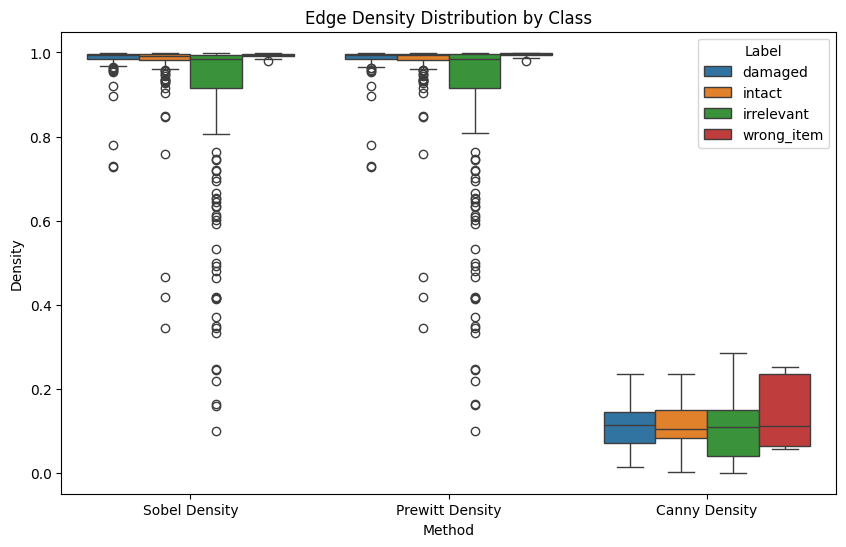

Edge Density Means by Class:


,Sobel Density,Prewitt Density,Canny Density
Label,,,
damaged,0.980182,0.980713,0.114821
intact,0.975174,0.975670,0.114755
irrelevant,0.887441,0.887947,0.101051
wrong_item,0.993774,0.994370,0.143160



ANOVA Results (Testing difference between classes):
Sobel Density: F-stat = 18.4181, p-value = 2.3067e-11
Prewitt Density: F-stat = 18.3999, p-value = 2.3634e-11
Canny Density: F-stat = 4.1515, p-value = 6.3699e-03

Classification Accuracy using ONLY Edge Densities (1D feature):
Sobel: 0.4712
Prewitt: 0.4327
Canny: 0.4231


In [16]:
if len(images) > 0:
    edge_density_means, anova_res, edge_acc = utils.analyze_edge_detection(images, labels, OUTPUT_DIR, knn_k=KNN_K)
    print("Edge Density Means by Class:")
    display(edge_density_means)
    
    print("\nANOVA Results (Testing difference between classes):")
    for method, res in anova_res.items():
        print(f"{method}: F-stat = {res['f_stat']:.4f}, p-value = {res['p_value']:.4e}")
        
    print("\nClassification Accuracy using ONLY Edge Densities (1D feature):")
    for method, acc in edge_acc.items():
        print(f"{method}: {acc:.4f}")

## **3. Summary and Discussion**
1. **Thay đổi Kích thước ảnh**: (Dựa vào đường cong SSIM, ghi nhận sự sụt giảm chất lượng và biện hộ cho kích thước phù hợp).
2. **Không gian màu**: (Xác nhận xem việc chuyển qua HSV hay LAB có giúp phân biệt class tốt hơn so với RGB không qua PCA và kNN).
3. **Chuẩn hóa**: (Kiểm định KS giúp khẳng định ý nghĩa thống kê của việc đưa đặc trưng về cùng phân phối).
4. **Augmentation**: (t-SNE có thể hiện được mức độ đa dạng hóa của mẫu khi nhiễu và xoay góc được đưa vào, tránh overfitting).
5. **PCA Components**: (Giúp xác định cần giữ lại bao nhiêu chiều để cân bằng hiệu năng và bộ nhớ cho mô hình máy học tiếp theo).
6. **Edge Density**: (ANOVA p-value < 0.05 sẽ cho thấy mức độ chi tiết và kết cấu cạnh là đặc trưng hữu ích cho việc phân loại hư hỏng hàng hóa).